# 4장 웹 스크레이핑을 사용한 데이터 분석

### 4-1 팬더스로 상장법인 목록 읽기

In [2]:
import pandas as pd
krx_list = pd.read_html('상장법인목|.xls')
krx_list[0]

In [14]:
krx_list[0].종목코드 = krx_list[0].종목코드.map('{:06d}'.format)
krx_list[0]

,회사명,종목코드,업종,주요제품,상장일,결산월,대표자명,홈페이지,지역
0,교보17호스팩,489210,금융 지원 서비스업,기업인수합병,2024-11-21,12월,장정훈,NaN,서울특별시
1,대신밸런스제19호스팩,482690,금융 지원 서비스업,기업 인수 및 합병,2024-11-20,12월,임병완,NaN,서울특별시
2,위츠,459100,전자부품 제조업,"무선충전소재, 부품 제조",2024-11-20,12월,김응태,http://www.ewits.co.kr/kr/,경기도
3,유디엠텍,389680,소프트웨어 개발 및 공급업,"PLC eXpert, OPTRA Black-box, OPTRA Tracker",2024-11-20,12월,왕지남,http://www.udmtek.com,경기도
4,사이냅소프트,466410,소프트웨어 개발 및 공급업,"웹 기반 문서뷰어, 문서필터, 웹 에디터 등",2024-11-19,12월,전경헌,http:///www.synapsoft.co.kr,서울특별시
...,...,...,...,...,...,...,...,...,...
2735,유한양행,000100,의약품 제조업,"의약품(삐콤씨, 안티푸라민, 렉라자, 로수바미브, 코푸시럽 등), 생활용품(유한락스...",1962-11-01,12월,대표이사 조욱제,http://www.yuhan.co.kr,서울특별시
2736,CJ대한통운,000120,도로 화물 운송업,"Contract Logistics, 포워딩, 항만하역, 해운, 택배국제특송, SCM...",1956-07-02,12월,"신영수, 민영학 (각자 대표)",http://www.cjlogistics.com,서울특별시
2737,경방,000050,종합 소매업,"섬유류(면사,면혼방사,면직물,면혼방직물,화섬사,화섬직물) 제조,도매,수출입",1956-03-03,12월,"김준, 김담",http://www.kyungbang.co.kr,서울특별시
2738,유수홀딩스,000700,회사 본부 및 경영 컨설팅 서비스업,지주사업,1956-03-03,12월,송영규,http://www.eusu-holdings.com,서울특별시


### 웹에서 일별 시세 구하기

In [3]:
from bs4 import BeautifulSoup
import requests
url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
bs = BeautifulSoup(html, 'lxml')
pgrr = bs.find('td', class_='pgRR')
print(pgrr.a['href'])

/item/sise_day.naver?code=068270&page=481


In [4]:
print(pgrr.prettify())

<td class="pgRR">
 <a href="/item/sise_day.naver?code=068270&amp;page=481">
  맨뒤
  <img alt="" border="0" height="5" src="https://ssl.pstatic.net/static/n/cmn/bu_pgarRR.gif" width="8"/>
 </a>
</td>



In [5]:
print(pgrr.text)


맨뒤
				




In [7]:
s = (pgrr.a['href'].split('='))
last_page = s[-1]
last_page

'481'

In [2]:
# 이거 에러나는 거 맞음
df = pd.DataFrame()
sise_url = 'https://finance.naver.com/item/sise_day.naver?code=068270'

for page in range(1, int(last_page)+1):
    url = '{}&page={}'.format(sise_url, page)
    html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
    df = df.append(pd.read_html(html, header=0[0]))

df = df.dropna()

C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will b

             날짜        종가        전일비        시가        고가        저가        거래량
1    2024.12.20  192500.0    상승  100  191100.0  193000.0  189600.0   408934.0
2    2024.12.19  192400.0  하락  6,800  194100.0  196500.0  192000.0   680416.0
3    2024.12.18  199200.0  상승  6,000  193200.0  199900.0  193200.0  6772005.0
4    2024.12.17  193200.0  하락  3,000  196000.0  196000.0  192000.0  1010402.0
5    2024.12.16  196200.0  상승  2,800  198000.0  198300.0  194700.0  1093284.0
..          ...       ...        ...       ...       ...       ...        ...
144  2024.07.31  204500.0  하락  4,500  209500.0  210500.0  200500.0  1022603.0
145  2024.07.30  209000.0        보합0  207000.0  211000.0  203500.0  1043589.0
146  2024.07.29  209000.0  상승  9,000  203000.0  210000.0  202000.0  1307248.0
147  2024.07.26  200000.0    상승  800  201500.0  204500.0  198100.0  1041632.0
148  2024.07.25  199200.0  상승  5,800  194000.0  205000.0  192100.0  2161673.0

[100 rows x 7 columns]


C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_list.append(pd.read_html(html, header=0)[0])
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\662665558.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will b

In [3]:
import pandas as pd
import requests

# 빈 DataFrame 생성
df = pd.DataFrame()

# 종목 코드와 페이지 수를 설정
sise_url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
last_page = 479

# 페이지별로 데이터 수집
for page in range(1, int(last_page) + 1):
    url = f'{sise_url}&page={page}'  # f-string을 사용하여 url 생성
    html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
    
    # HTML에서 테이블 읽기
    tables = pd.read_html(html, header=0)[0]
    
    # 기존 DataFrame과 새로운 DataFrame을 병합
    df = pd.concat([df, tables], ignore_index=True)

# NaN 값 제거
df = df.dropna()

# 결과 확인
print(df);


C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future

              날짜        종가        전일비        시가        고가        저가        거래량
1     2024.12.20  192500.0    상승  100  191100.0  193000.0  189600.0   408934.0
2     2024.12.19  192400.0  하락  6,800  194100.0  196500.0  192000.0   680416.0
3     2024.12.18  199200.0  상승  6,000  193200.0  199900.0  193200.0  6772005.0
4     2024.12.17  193200.0  하락  3,000  196000.0  196000.0  192000.0  1010402.0
5     2024.12.16  196200.0  상승  2,800  198000.0  198300.0  194700.0  1093284.0
...          ...       ...        ...       ...       ...       ...        ...
7179  2005.08.09    4925.0     하락  65    4860.0    5200.0    4860.0    25364.0
7180  2005.08.08    4990.0     하락  10    4850.0    5100.0    4850.0     9562.0
7181  2005.08.05    5000.0    하락  150    5020.0    5050.0    4930.0    17983.0
7182  2005.08.04    5150.0    상승  120    5050.0    5230.0    5050.0    18127.0
7183  2005.08.03    5030.0    하락  270    5220.0    5320.0    5030.0    31604.0

[4790 rows x 7 columns]


C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html, header=0)[0]
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\796610667.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future

### 4.5 OHLC와 캔들 차트

C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\526584056.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\526584056.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\526584056.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\526584056.py:21: 

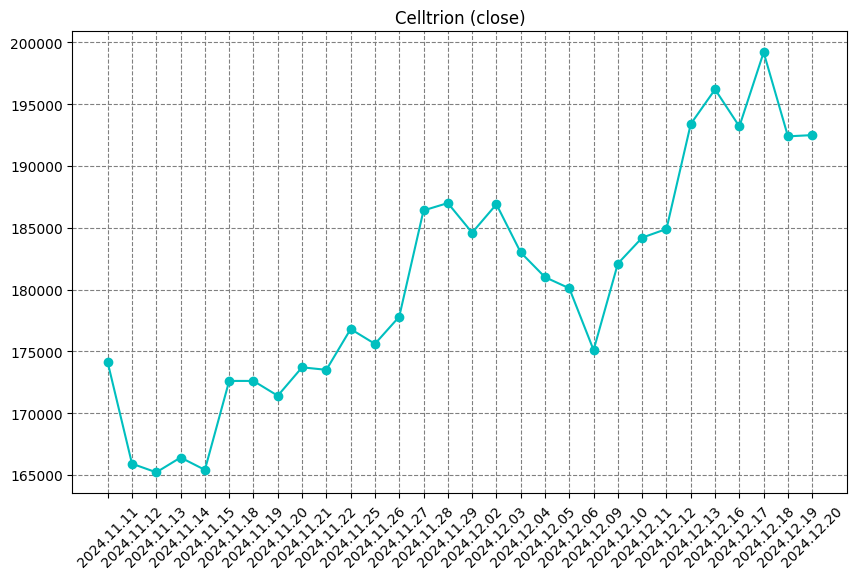

In [ ]:
# ch04_01 Celltrion_PlotChart
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# 맨 뒤 페이지 숫자 구하기
url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
bs = BeautifulSoup(html, 'lxml')
pgrr = bs.find('td', class_='pgRR')
s = (pgrr.a['href'].split('='))
last_page = s[-1]

# 전체 페이지 읽어오기
df = pd.DataFrame()
sise_url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
for page in range(1, int(last_page) + 1):
    url = f'{sise_url}&page={page}'
    html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
    df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)

# 차트 출력을 위한 데이터 가공
df = df.dropna()
df = df.iloc[0:30] # 최근 30일의 데이터만 사용
df = df.sort_values(by='날짜') # 날짜 기준으로 오름차순 정렬 (네이버 금융의 데이터가 내림차순)

# 날짜, 종가 컬럼으로 차트 그리기
plt.figure(figsize=(10, 6))
plt.title('Celltrion (close)')
plt.xticks(rotation=45)
plt.plot(df['날짜'], df['종가'], 'co-') # x축:날짜, y축:종가, 청색(c) + 원형(o) + 실선(-)
plt.grid(color='gray', linestyle='--')
plt.show()

C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\2000217908.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\2000217908.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\2000217908.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)
C:\Users\kys07\AppData\Local\Temp\ipykernel_14744\2000217908.py:

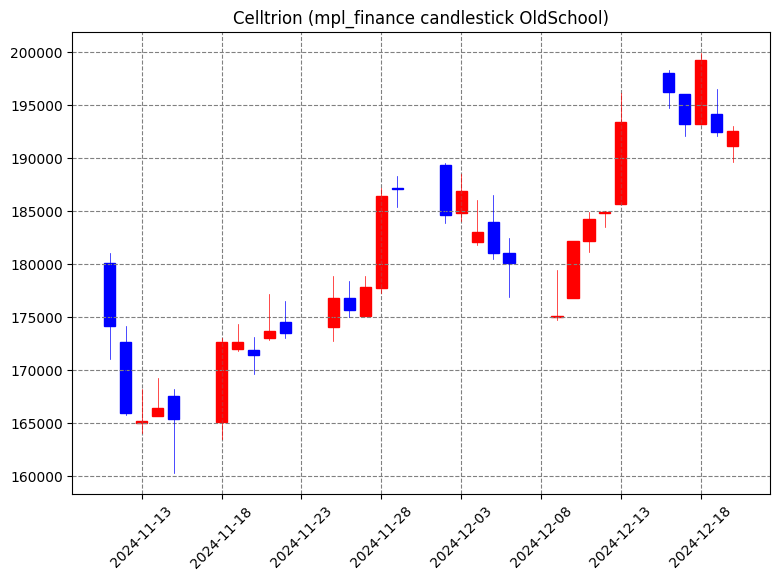

In [15]:
# ch04_02 Celltrion_CandleChart(OldSchool)
# 셀트리온 캔들 차트 구버전

import pandas as pd
import requests
from bs4 import BeautifulSoup
from matplotlib import pyplot as plt
from matplotlib import dates as mdates
from mpl_finance import candlestick_ohlc
from datetime import datetime

# 맨 뒤 페이지 숫자 구하기
url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
bs = BeautifulSoup(html, 'lxml')
pgrr = bs.find('td', class_='pgRR')
s = (pgrr.a['href'].split('='))
last_page = s[-1]

# 전체 페이지 읽어오기
df = pd.DataFrame()
sise_url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
for page in range(1, int(last_page) + 1):
    url = f'{sise_url}&page={page}'
    html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
    df = pd.concat([df, pd.read_html(html, header=0)[0]], ignore_index=True)

# 차트 출력을 위한 데이터 가공
df = df.dropna()
df = df.iloc[0:30] # 최근 30일의 데이터만 사용
df = df.sort_values(by='날짜')
for idx in range(0, len(df)):
    dt = datetime.strptime(df['날짜'].values[idx], '%Y.%m.%d').date() # 날짜를 문자열에서 datetime으로 변환
    df['날짜'].values[idx] = mdates.date2num(dt) # 위에서의 datetime을 float형으로 변환

# 날짜, 시가, 고가, 저가, 종가 컬럼만 갖는 별도의 DF 생성, candlestick_ohlc() 함수를 호출할 때 두 번째 인수로 사용
ohlc = df[['날짜', '시가', '고가', '저가', '종가']] 

# 엠피엘_파이낸스로 캔들 차트 그리기
plt.figure(figsize=(9, 6))
ax = plt.subplot(1, 1, 1)
plt.title('Celltrion (mpl_finance candlestick OldSchool)')
candlestick_ohlc(ax, ohlc.values, width=0.7, colorup='red', colordown='blue') # 캔들 차트 그리기
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # x축에 날짜 출력
plt.xticks(rotation=45)
plt.grid(color='gray', linestyle='--')
plt.show()

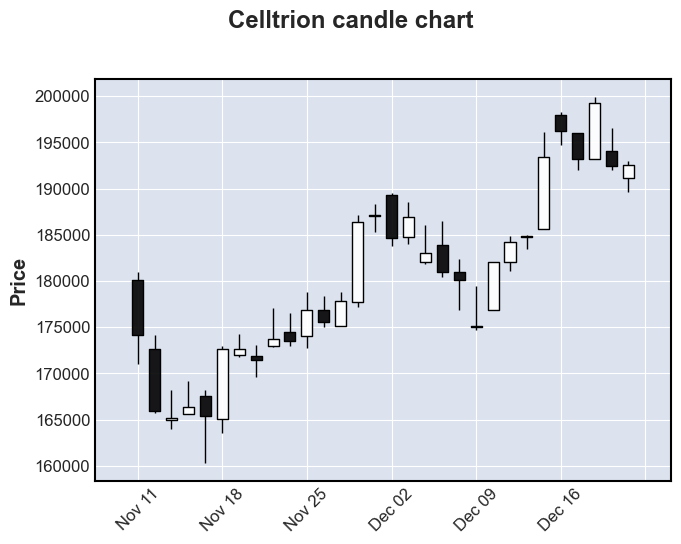

In [20]:
# ch04_03 Celltrion_CandleChart(NewSchool)
# 셀트리온 캔들 차트 신버전

import pandas as pd
import requests
from bs4 import BeautifulSoup
import mplfinance as mpf
from io import StringIO # 문자열을 파일처럼 다루기 위한 StringIO 모듈 html 경고 때문에

# 맨 뒤 페이지 숫자 구하기
url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
html_io = StringIO(html) # 이렇게 하면 에러 안 남
bs = BeautifulSoup(html, 'lxml')
pgrr = bs.find('td', class_='pgRR')
s = (pgrr.a['href'].split('='))
last_page = s[-1]

# 전체 페이지 읽어오기
df = pd.DataFrame()
sise_url = 'https://finance.naver.com/item/sise_day.naver?code=068270'
for page in range(1, int(last_page) + 1):
    url = f'{sise_url}&page={page}'
    html = requests.get(url, headers={'User-agent': 'Mozilla/5.0'}).text
    html_io = StringIO(html)
    df = pd.concat([df, pd.read_html(html_io, header=0)[0]], ignore_index=True)

# 차트 출력을 위한 데이터 가공
df = df.dropna()
df = df.iloc[0:30] # 최근 30일의 데이터만 사용
df = df.rename(columns={'날짜': 'Date', '시가': 'Open', '고가': 'High', '저가': 'Low', '종가': 'Close', '거래량': 'Volume'})
df = df.sort_values(by='Date')
df.index = pd.to_datetime(df.Date) # Date 컬럼을 DatetimeIndex형으로 변경 후 인덱스로 지정
df = df[['Open', 'High', 'Low', 'Close', 'Volume']] # Date 컬럼 제외

# 캔들 차트 그리기
mpf.plot(df, title='Celltrion candle chart', type='candle'); # type 기본은 ohlc

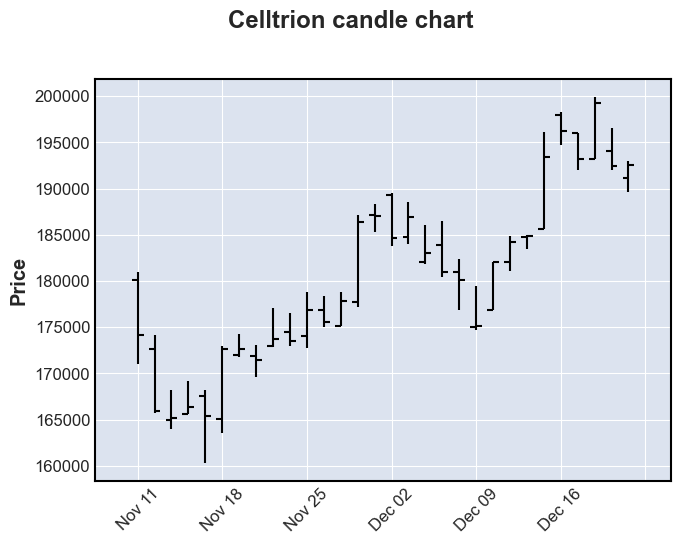

In [21]:
mpf.plot(df, title='Celltrion candle chart', type='ohlc');

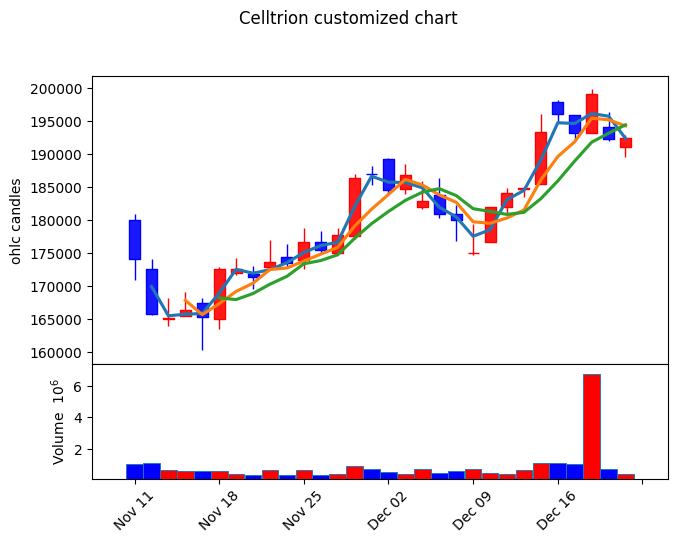

In [23]:
"""
- 색상 바꾸기
- 차트 하단에 거래량 그래프 표시
- 이동평균선 출력
"""
kwargs = dict(title='Celltrion customized chart', type='candle', mav=(2, 4, 6), volume=True, ylabel='ohlc candles')
mc = mpf.make_marketcolors(up='r', down='b', inherit=True)
s = mpf.make_mpf_style(marketcolors=mc)
mpf.plot(df, **kwargs, style=s)